<a href="https://colab.research.google.com/github/imets01/synthetic_network_data_gen/blob/anna/low_level_features/low_level_synthetic_data_PARSynthetizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install torch pandas numpy scikit-learn tqdm

Note: you may need to restart the kernel to use updated packages.


## Trying out PARSynthetizer from SDV

In [2]:
%pip install sdv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 198.5/198.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 198.5/198.5 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 42.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
from sdv.sequential import PARSynthesizer
from sdv.metadata import Metadata
import pandas as pd

In [4]:
data = pd.read_csv("https://raw.githubusercontent.com/imets01/synthetic_network_data_gen/refs/heads/anna/low_level_features/dataset/all_low_level_features_merged.csv")

In [5]:
data.head(20)

,frame_number,delta_time,packet_length,packet_direction,header_form,count_initial,count_0rtt,count_handshake,count_1rtt,count_retry,...,count_new_connection_id,count_retire_cid,count_ping,count_crypto,count_handshake_done,http3_stream_count,http3_fin_count,stream_length,stream_type_count,capture_id
0,1,0.000000,1242,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,10000
1,2,0.000087,89,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,10000
2,3,0.000554,1242,0,1,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,10000
3,4,0.001087,1242,1,1,1,0,1,0,0,...,0,0,0,4,0,0,0,0,0,10000
4,5,0.000021,403,1,1,0,0,1,0,0,...,0,0,0,2,0,0,0,0,0,10000
5,6,0.003077,1392,0,1,1,0,1,1,0,...,1,0,0,1,0,0,0,0,0,10000
6,7,0.000251,623,1,0,0,0,0,1,0,...,1,0,0,2,1,2,0,10,1,10000
7,8,0.000153,85,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,10000
8,9,0.000098,1392,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,10000
9,10,0.000032,1242,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,10000


In [6]:
df_clean = data[~data['capture_id'].isin(data.loc[data.lt(0).any(axis=1), 'capture_id'])]

In [7]:
df_clean

,frame_number,delta_time,packet_length,packet_direction,header_form,count_initial,count_0rtt,count_handshake,count_1rtt,count_retry,...,count_new_connection_id,count_retire_cid,count_ping,count_crypto,count_handshake_done,http3_stream_count,http3_fin_count,stream_length,stream_type_count,capture_id
0,1,0.000000,1242,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,10000
1,2,0.000087,89,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,10000
2,3,0.000554,1242,0,1,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,10000
3,4,0.001087,1242,1,1,1,0,1,0,0,...,0,0,0,4,0,0,0,0,0,10000
4,5,0.000021,403,1,1,0,0,1,0,0,...,0,0,0,2,0,0,0,0,0,10000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261191,23,0.000215,75,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,9
261192,24,0.000054,147,0,0,0,0,0,1,0,...,0,0,0,0,0,1,1,72,1,9
261193,25,0.000193,101,0,0,0,0,0,1,0,...,0,0,0,0,0,1,1,26,1,9
261194,26,0.001212,310,1,0,0,0,0,1,0,...,0,0,0,0,0,1,1,230,1,9


In [8]:
data = df_clean

In [9]:
metadata = Metadata.detect_from_dataframe(data)

In [10]:
def update_metadata(metadata, cols, correct_metadata, computer_representation = None):
  for i in range(len(cols)):
    metadata.update_column(
      column_name=cols[i],
      sdtype=correct_metadata,
    )
    if computer_representation is not None:
      metadata.update_column(
        column_name=cols[i],
        computer_representation=computer_representation,
      )
  return metadata

In [11]:
integer_cols = ['packet_length', 'count_initial', 'count_0rtt', 'count_handshake',
                'count_retry', 'count_vn', 'count_1rtt', 'count_ack', 'count_padding', 'count_connection_close',
                'count_path_challenge', 'count_path_response', 'count_new_connection_id',
                'count_retire_cid', 'count_crypto', 'count_handshake_done', 'count_ping', 'http3_stream_count',
                'http3_fin_count', 'stream_length', 'stream_type_count']
binary_cols = ['packet_direction', 'header_form']

In [12]:
metadata = update_metadata(metadata, binary_cols, 'boolean')
metadata = update_metadata(metadata, integer_cols, 'numerical', 'Int64')


In [13]:
metadata.set_sequence_key('capture_id')

In [14]:
metadata.set_sequence_index('frame_number')

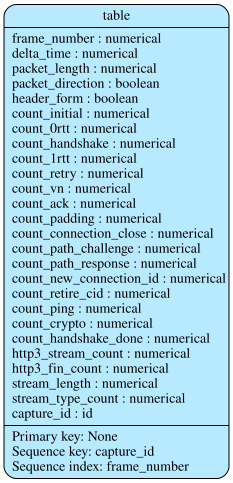

In [15]:
metadata.visualize()

In [16]:
data[binary_cols] = data[binary_cols].astype(bool)

In [17]:
import torch
torch.cuda.is_available()

True

In [18]:
value_counts = pd.DataFrame(data['capture_id'].value_counts())

Min length: count    1
dtype: int64
Mean length: count    21.936026
dtype: float64
Max length: count    32
dtype: int64


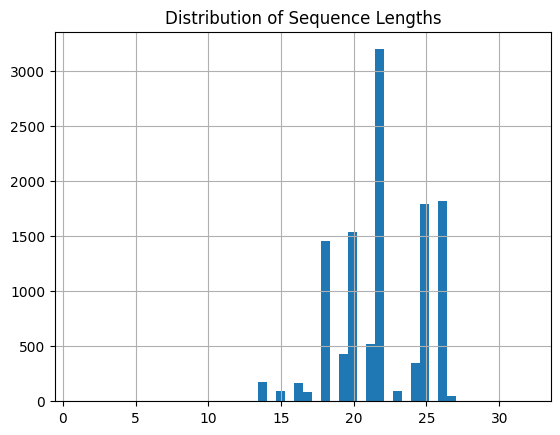

In [19]:
print("Min length:", value_counts.min())
print("Mean length:", value_counts.mean())
print("Max length:", value_counts.max())  # <--- If this is > 500, that's your problem.

# Visual check (optional)
import matplotlib.pyplot as plt
value_counts.hist(bins=50)
plt.title("Distribution of Sequence Lengths")
plt.show()

In [20]:
value_counts.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11786 entries, 10055 to 11896
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   count   11786 non-null  int64
dtypes: int64(1)
memory usage: 184.2 KB


In [21]:
valid_ids = value_counts[value_counts['count']>10].index

In [22]:
clean_data = data[data['capture_id'].isin(valid_ids)]

In [23]:
clean_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 258474 entries, 0 to 261195
Data columns (total 26 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   frame_number             258474 non-null  int64  
 1   delta_time               258474 non-null  float64
 2   packet_length            258474 non-null  int64  
 3   packet_direction         258474 non-null  bool   
 4   header_form              258474 non-null  bool   
 5   count_initial            258474 non-null  int64  
 6   count_0rtt               258474 non-null  int64  
 7   count_handshake          258474 non-null  int64  
 8   count_1rtt               258474 non-null  int64  
 9   count_retry              258474 non-null  int64  
 10  count_vn                 258474 non-null  int64  
 11  count_ack                258474 non-null  int64  
 12  count_padding            258474 non-null  int64  
 13  count_connection_close   258474 non-null  int64  
 14  count_pat

In [24]:
from sdv.sequential import PARSynthesizer

synthesizer = PARSynthesizer(metadata, verbose=True, epochs=100, cuda=True)
synthesizer.fit(clean_data)

synthetic_data = synthesizer.sample(num_sequences=100)

/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
100%|██████████| 100/100 [01:06<00:00,  1.51it/s]


In [25]:
counts = (
    synthetic_data
    .groupby('capture_id')
    .size()
    .reset_index(name='count')
)


In [26]:
counts = counts.sort_values('count', ascending=False)


In [27]:
counts

,capture_id,count
2,445216,32
6,1116383,32
5,570476,32
4,551541,32
28,5191983,32
...,...,...
16,2250831,11
25,4396217,11
64,10922874,11
51,8977992,11


In [28]:
pd.set_option('display.max_columns', None)

In [29]:
synthetic_data['capture_id'].unique()

array([ 3159657, 16362634,  7774611, 10283550, 16350913, 15212201,
        8208835, 13788622,  2867805, 14747537,  1844631, 12933060,
        1463802,  9619371, 11952842,  2469358, 14636835,  1584710,
         551541, 16456581, 15725696,  7121173, 10354861,  6325999,
       10637536,  9281085, 15435275, 16460566,  2859575,  6048978,
        7516191,  6667603,  4826897,  5313135,  4021841, 10410080,
       12898345, 15398994, 15137660, 13387661,  8977992, 15000062,
        5191983,  6424012, 15230860,  6217962, 13603171,  9566000,
       13011589,  8035586,  8707394,    34454,  3756465,  4430091,
       10922874,   270570,   445216,   570476,  1179570, 10695832,
        5216784,   545378, 13228355,  6738250,  8311687,  1373841,
        9784385,  3501700,  1425469, 15821246, 13982473, 10697606,
       16146291, 11841134,  2132364,  6814582,  4396217,  6359885,
        7327507, 12196972,  6833606, 14391901,  2001697, 11352435,
       14969921,  1565020, 11646095, 16102650,  6725139, 11908

In [30]:
# Save to the specific working directory
save_path = '/kaggle/working/par_synthesizer_10.pkl'
synthesizer.save(filepath=save_path)

print(f"Model saved to: {save_path}")

Model saved to: /kaggle/working/par_synthesizer_10.pkl


In [31]:
synthetic_data

,frame_number,delta_time,packet_length,packet_direction,header_form,count_initial,count_0rtt,count_handshake,count_1rtt,count_retry,count_vn,count_ack,count_padding,count_connection_close,count_path_challenge,count_path_response,count_new_connection_id,count_retire_cid,count_ping,count_crypto,count_handshake_done,http3_stream_count,http3_fin_count,stream_length,stream_type_count,capture_id
0,1,0.007387,761,False,True,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,26,0,3159657
1,2,0.000000,383,True,False,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,3159657
2,3,0.009702,401,True,True,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,3159657
3,4,0.013377,359,False,False,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,26,1,3159657
4,5,0.007387,61,False,False,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3159657
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2485,28,0.000000,368,True,True,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,40,0,5492773
2486,29,0.079038,595,False,False,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5492773
2487,30,0.032167,553,True,False,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,209,0,5492773
2488,31,0.019055,390,False,False,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,96,1,5492773


In [32]:
output_path = '/kaggle/working/my_final_dataframe.csv'

synthetic_data.to_csv(output_path, index=False)

print(f"✅ DataFrame successfully saved to: {output_path}")

✅ DataFrame successfully saved to: /kaggle/working/my_final_dataframe.csv


In [33]:
pd.set_option('display.max_columns', None)

In [34]:
pd.set_option('display.max_rows', None)